In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def C(x,t,a,k):
    xi =  np.linspace(0.0001,50,10000)
    integrant = (np.sin (xi)/xi)*(np.cos (x*xi))* np.exp(-(k + a * xi**2)*t) 
    return (2/np.pi)*np.trapezoid(integrant,xi)
    

In [9]:
print (C(0,0.1,1,1))

0.8818446119746624


In [21]:
x_values = np.linspace(-4,4,200)
t = 0.5
a = 1
k = 1
c_values = np.array([C(x,t,a,k) for x in x_values])

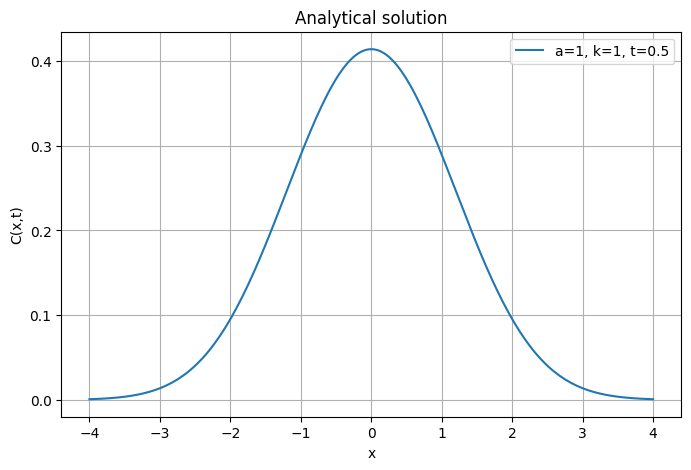

In [22]:
plt.figure(figsize = (8,5))
plt.plot(x_values, c_values, label = f'a={a}, k={k}, t={t}')
plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title('Analytical solution')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
a_values  = [0.1, 0.5, 1.0, 2.0]

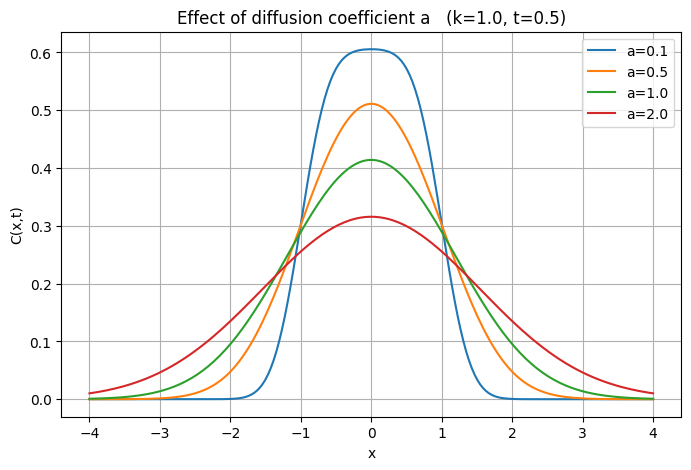

In [24]:
t = 0.5
k = 1.0
a_values = [0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(8, 5))
for a in a_values:
    C_values = np.array([C(x, t, a, k) for x in x_values])
    plt.plot(x_values, C_values, label=f'a={a}')
plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title(f'Effect of diffusion coefficient a   (k={k}, t={t})')
plt.legend()
plt.grid(True)
plt.show()

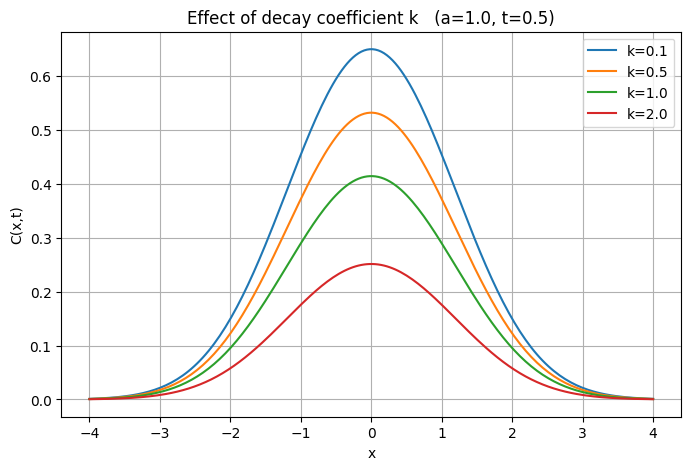

In [27]:
t = 0.5
a = 1.0
k_values = [0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(8, 5))
for k in k_values:
    C_values = np.array([C(x, t, a, k) for x in x_values])
    plt.plot(x_values, C_values, label=f'k={k}')
plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title(f'Effect of decay coefficient k   (a={a}, t={t})')
plt.legend()
plt.grid(True)
plt.show()

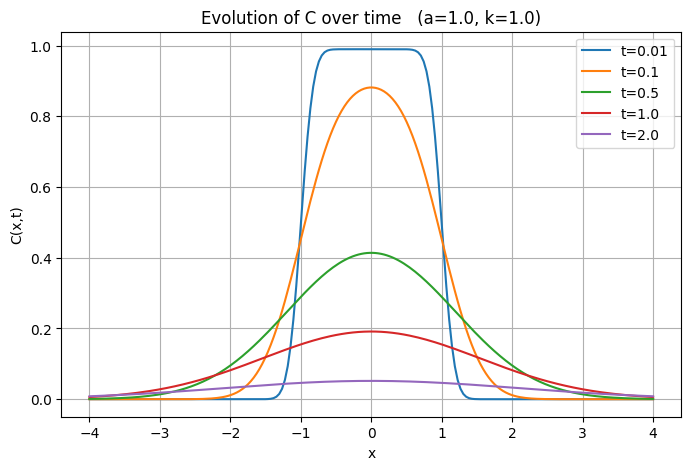

In [28]:
a = 1.0
k = 1.0
t_values = [0.01,0.1,0.5,1.0,2.0]
plt.figure(figsize=(8, 5))
for t in t_values:
    C_values = np.array([C(x,t,a,k) for x in x_values])
    plt.plot(x_values, C_values, label=f't={t}')

plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title(f'Evolution of C over time   (a={a}, k={k})')
plt.legend()
plt.grid(True)
plt.show()

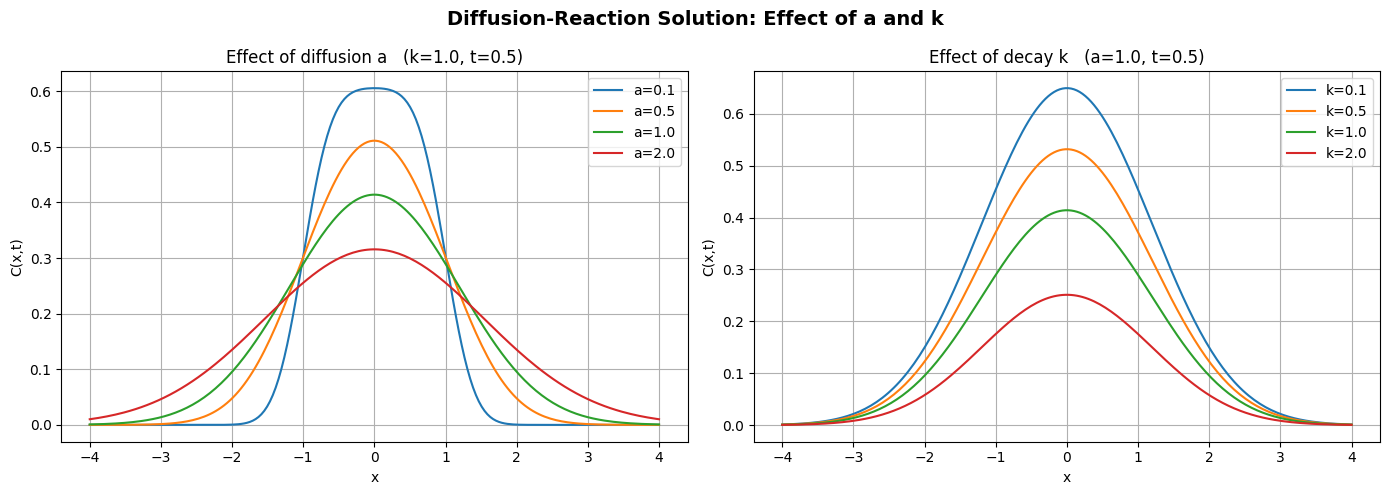

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t = 0.5
k = 1.0
a_values = [0.1,0.5,1.0,2.0]
for a in a_values:
    C_values = np.array([C(x,t,a,k) for x in x_values])
    axes[0].plot(x_values, C_values, label=f'a={a}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('C(x,t)')
axes[0].set_title(f'Effect of diffusion a   (k={k}, t={t})')
axes[0].legend()
axes[0].grid(True)
a = 1.0
k_values = [0.1,0.5,1.0,2.0]
for k in k_values:
    C_values = np.array([C(x,t,a,k) for x in x_values])
    axes[1].plot(x_values, C_values, label=f'k={k}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('C(x,t)')
axes[1].set_title(f'Effect of decay k   (a={a}, t={t})')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Diffusion-Reaction Solution: Effect of a and k', 
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
a = 1.0
k = 0.1
# Grid1(coarse)
dx1 = 0.2
dt1 = 0.02
#Grid2(fine)
dx2 = 0.1
dt2 = 0.004
#Stability check
r1 = a * dt1 / dx1**2
r2 = a * dt2 / dx2**2
print(f'Grid 1: r = {r1}')
print(f'Grid 2: r = {r2}')

Grid 1: r = 0.4999999999999999
Grid 2: r = 0.3999999999999999


In [31]:
#spatial grid
x_left  = -5
x_right =  5
x1 = np.arange(x_left,x_right + dx1,dx1)  #coarse grid
x2 = np.arange(x_left,x_right + dx2,dx2)  #fine grid
#IC - c(x,0)
def initial_condition(x):
    return np.where(np.abs(x) < 1, 1.0, 0.0)
C1 = initial_condition(x1)  #coarse
C2 = initial_condition(x2)  #fine
print(f'Coarse grid:{len(x1)} points')
print(f'Fine grid:{len(x2)} points')
print(f'C1 at x=0:{C1[len(x1)//2]}')
print(f'C2 at x=0:{C2[len(x2)//2]}')

Coarse grid:51 points
Fine grid:101 points
C1 at x=0:1.0
C2 at x=0:1.0


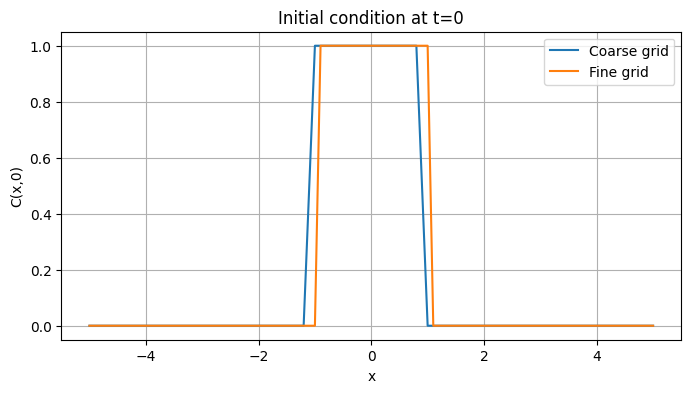

In [33]:
plt.figure(figsize=(8,4))
plt.plot(x1, C1, label='Coarse grid')
plt.plot(x2, C2, label='Fine grid')
plt.xlabel('x')
plt.ylabel('C(x,0)')
plt.title('Initial condition at t=0')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
def explicit_fd(x,dx,dt,a,k,t_end):
   #timesteps
    nt = int(t_end/dt)
    #IC
    C = initial_condition(x)
    #Stability check
    r = a * dt/dx**2
    print(f'r = {r:.4f}')
    #timesteploop
    for n in range(nt):
        C_new = C.copy()
        for i in range(1, len(x)-1):
            C_new[i] = C[i]+dt*((a * (C[i+1] - 2*C[i] + C[i-1])/dx**2)-k*C[i])
        #BC
        C_new[0]  = 0.0
        C_new[-1] = 0.0
        C = C_new
    return C

r = 0.5000
r = 0.4000


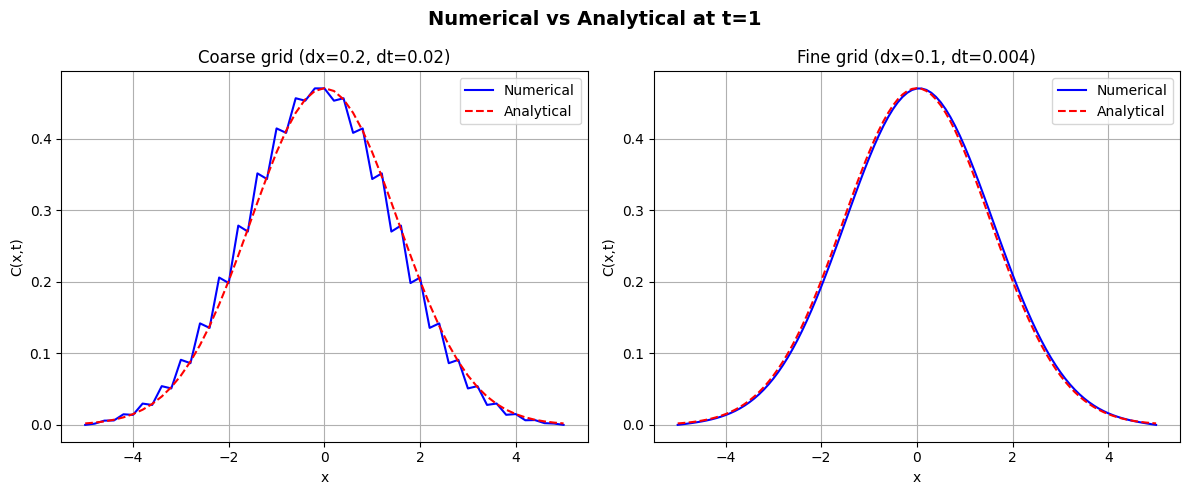

In [36]:
#running both grid
C1_numerical = explicit_fd(x1,dx1,dt1,a,k,t_end=1.0)
C2_numerical = explicit_fd(x2,dx2,dt2,a,k,t_end=1.0)
#Analytical solution at t=1
t_final = 1.0
C1_analytical = np.array([C(x, t_final,a,k) for x in x1])
C2_analytical = np.array([C(x, t_final,a,k) for x in x2])






plt.figure(figsize=(12, 5))
# Left-coarse grid
plt.subplot(1, 2, 1)
plt.plot(x1, C1_numerical,  'b-',  label='Numerical')
plt.plot(x1, C1_analytical, 'r--', label='Analytical')
plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title(f'Coarse grid (dx={dx1}, dt={dt1})')
plt.legend()
plt.grid(True)

# Right-fine grid
plt.subplot(1, 2, 2)
plt.plot(x2, C2_numerical,  'b-',  label='Numerical')
plt.plot(x2, C2_analytical, 'r--', label='Analytical')
plt.xlabel('x')
plt.ylabel('C(x,t)')
plt.title(f'Fine grid (dx={dx2}, dt={dt2})')
plt.legend()
plt.grid(True)

plt.suptitle('Numerical vs Analytical at t=1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
def L2_error(C_numerical,C_analytical,dx):
    error = C_numerical-C_analytical
    return np.sqrt(np.sum(error**2)*dx)
error1 = L2_error(C1_numerical, C1_analytical,dx1)
error2 = L2_error(C2_numerical, C2_analytical,dx2)



print(f'Coarse grid (dx={dx1}): L2 error = {error1:.6f}')
print(f'Fine grid   (dx={dx2}): L2 error = {error2:.6f}')

Coarse grid (dx=0.2): L2 error = 0.056583
Fine grid   (dx=0.1): L2 error = 0.017975


In [38]:
# Define three grids
grids = [
    {'dx': 0.4,  'dt': 0.07},
    {'dx': 0.2,  'dt': 0.02},
    {'dx': 0.1,  'dt': 0.004},
]
# Store results
dx_values    = []
error_values = []
for grid in grids:
    dx = grid['dx']
    dt = grid['dt']
    # check stability
    r = a * dt / dx**2
    print(f'dx={dx}, dt={dt}, r={r:.4f}')
    # set up grid
    x = np.arange(-5, 5 + dx, dx)
    # run numerical solution
    C_num = explicit_fd(x, dx, dt, a, k, t_end=1.0)
    # analytical solution on same grid
    C_ana = np.array([C(xi, 1.0, a, k) for xi in x])
    # compute L2 error
    err = L2_error(C_num, C_ana, dx)
    print(f'L2 error = {err:.6f}\n')
    dx_values.append(dx)
    error_values.append(err)

dx=0.4, dt=0.07, r=0.4375
r = 0.4375
L2 error = 0.071844

dx=0.2, dt=0.02, r=0.5000
r = 0.5000
L2 error = 0.056583

dx=0.1, dt=0.004, r=0.4000
r = 0.4000
L2 error = 0.017975



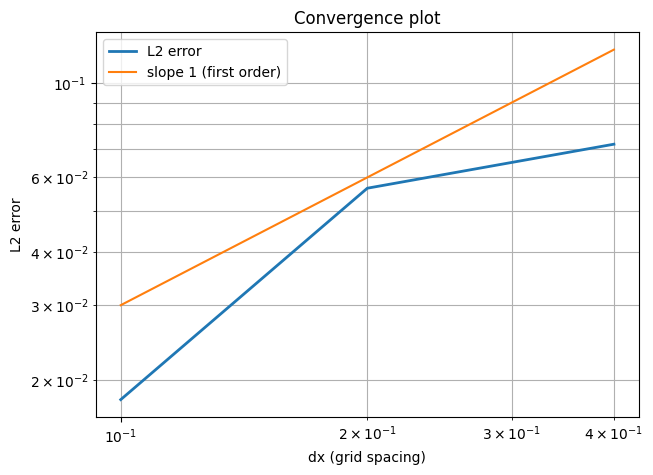

In [40]:
plt.figure(figsize=(7, 5))
plt.loglog(dx_values, error_values, 
           linewidth=2, markersize=8, label='L2 error')
dx_ref = np.array(dx_values)
plt.loglog(dx_ref, 0.3 * dx_ref**1, label='slope 1 (first order)')
plt.xlabel('dx (grid spacing)')
plt.ylabel('L2 error')
plt.title('Convergence plot')
plt.legend()
plt.grid(True, which='both')
plt.show()